# Delivery and Satisfaction Analysis

Does late delivery hurt customer satisfaction, by how much, and does it reduce the chance
that a customer comes back?

Late means the order arrived on a later calendar day than promised (defined in notebook 02).

In [4]:
import pandas as pd
import numpy as np
import sqlite3
from scipy import stats
import matplotlib.pyplot as plt

orders = pd.read_csv('../data/order_level.csv')

# One review per order: keep the earliest (audit finding 3)
conn = sqlite3.connect('../olist.db')
reviews = pd.read_sql_query(
    "SELECT order_id, review_score, review_creation_date, review_answer_timestamp FROM reviews", conn)
conn.close()

reviews = reviews.sort_values('review_creation_date')
reviews = reviews.drop_duplicates(subset='order_id', keep='first')

df = orders.merge(reviews[['order_id', 'review_score', 'review_creation_date', 'review_answer_timestamp']],
                  on='order_id', how='left')
print("Orders:", len(df))

# CSV stores the buckets as plain text, so restore their early-to-late order
bucket_order = ['Early', 'On promised day', '1-3 days late',
                '4-7 days late', '8-14 days late', '15+ days late']
df['delay_bucket'] = pd.Categorical(df['delay_bucket'],
                                    categories=bucket_order, ordered=True)

# Review analysis uses only orders that actually have a review
reviewed = df[df['review_score'].notna()].copy()
print("Orders with a review:", len(reviewed))
print("Excluded because no review:", len(df) - len(reviewed))

Orders: 96470
Orders with a review: 95824
Excluded because no review: 646


In [5]:
on_time = reviewed[reviewed['is_late'] == 0]['review_score']
late = reviewed[reviewed['is_late'] == 1]['review_score']

print("ON-TIME orders:", len(on_time))
print("  Average score:", round(on_time.mean(), 2))
print("  Share of 1-2 star reviews:", round((on_time <= 2).mean() * 100, 1), "%")
print()
print("LATE orders:", len(late))
print("  Average score:", round(late.mean(), 2))
print("  Share of 1-2 star reviews:", round((late <= 2).mean() * 100, 1), "%")
print()

# Welch's t-test: is the difference in averages larger than chance would produce?
t_stat, p_value = stats.ttest_ind(on_time, late, equal_var=False)
print("Welch's t-test")
print("  t-statistic:", round(t_stat, 2))
print("  p-value:", p_value)
print()

# Cohen's d: how big is the difference, in units of the typical spread of scores?
n1 = len(on_time)
n2 = len(late)
s1 = on_time.std()
s2 = late.std()
pooled_sd = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
cohens_d = (on_time.mean() - late.mean()) / pooled_sd
print("Cohen's d:", round(cohens_d, 2))

ON-TIME orders: 89443
  Average score: 4.29
  Share of 1-2 star reviews: 9.3 %

LATE orders: 6381
  Average score: 2.27
  Share of 1-2 star reviews: 62.4 %

Welch's t-test
  t-statistic: 100.64
  p-value: 0.0

Cohen's d: 1.71


### Result: late orders are rated far worse

| | On time | Late |
|---|---|---|
| Orders with a review | 89,443 | 6,381 |
| Average score | 4.29 | 2.27 |
| Share of 1–2 star reviews | 9.3% | 62.4% |

Most late orders receive a negative review, and a late order is about 6.7 times more likely
to be rated 1–2 stars. Late orders make up under 7% of reviewed orders but roughly a third
of all negative reviews.

The difference is statistically significant (Welch's t-test, p < 0.001). Welch's version is
used because the two groups differ greatly in size and spread. With over 95,000 orders
almost any difference would be significant, so effect size is reported as well: Cohen's
d = 1.71, more than double the conventional threshold for a large effect.

                 orders  avg_score  pct_1_2_star
delay_bucket                                    
Early             88163       4.29           9.2
On promised day    1280       4.04          12.3
1-3 days late      1852       3.29          32.2
4-7 days late      1748       2.11          67.6
8-14 days late     1446       1.67          80.2
15+ days late      1335       1.73          78.2


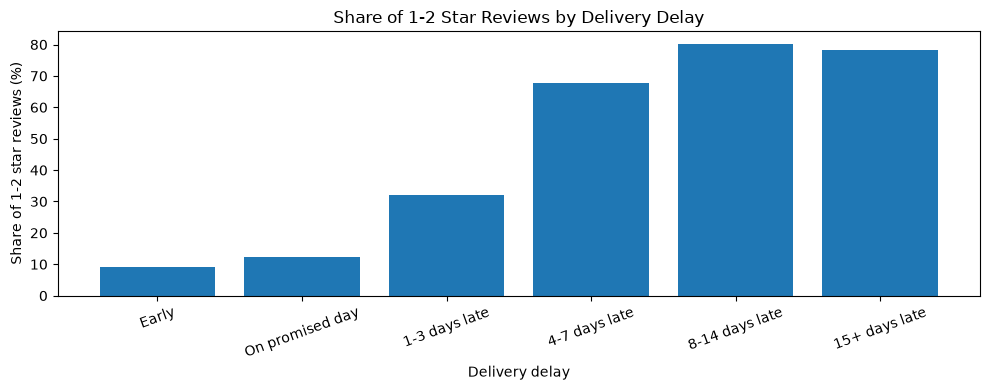

In [6]:
# Flag each review as negative (1 or 2 stars) so we can average it into a share
reviewed['is_negative'] = (reviewed['review_score'] <= 2).astype(int)

# observed=True: only show buckets that actually contain orders
grouped = reviewed.groupby('delay_bucket', observed=True)

by_bucket = pd.DataFrame({
    'orders': grouped['review_score'].count(),
    'avg_score': grouped['review_score'].mean().round(2),
    'pct_1_2_star': (grouped['is_negative'].mean() * 100).round(1)
})
print(by_bucket)

# Chart: share of negative reviews in each bucket
plt.figure(figsize=(10, 4))
plt.bar(by_bucket.index.astype(str), by_bucket['pct_1_2_star'])
plt.title('Share of 1-2 Star Reviews by Delivery Delay')
plt.xlabel('Delivery delay')
plt.ylabel('Share of 1-2 star reviews (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../outputs/negative_reviews_by_delay_bucket.png', dpi=150)
plt.show()

### Result: satisfaction collapses through the first week of lateness

| Delay | Orders | Average score | 1–2 star reviews |
|---|---|---|---|
| Early | 88,163 | 4.29 | 9.2% |
| On promised day | 1,280 | 4.04 | 12.3% |
| 1–3 days late | 1,852 | 3.29 | 32.2% |
| 4–7 days late | 1,748 | 2.11 | 67.6% |
| 8–14 days late | 1,446 | 1.67 | 80.2% |
| 15+ days late | 1,335 | 1.73 | 78.2% |

**Orders delivered on the promised day behave like on-time orders.** Their negative-review
rate of 12.3% is close to that of early orders and far below any late bucket, confirming the
corrected late definition. It is slightly above the early rate, so arriving on the deadline
is a little less satisfying than arriving ahead of it.

**Even a small delay is costly.** Orders one to three days late are three and a half times
more likely than early orders to receive a negative review.

**The damage builds through the first week, then levels off.** The largest jump is between
the first and second late buckets. Beyond a week late, around 80% of orders receive a
negative review, and further delay makes little difference.

**The plateau reflects review timing.** Beyond a week late, almost every review was written
before the order arrived, and pre-arrival reviews are around 80% negative regardless of the
delay. See the review timing check below.

In [7]:
# Get the actual delivery date for each order
conn = sqlite3.connect('../olist.db')
delivered_dates = pd.read_sql_query(
    "SELECT order_id, order_delivered_customer_date FROM orders", conn)
conn.close()

rows_before = len(reviewed)
reviewed = reviewed.merge(delivered_dates, on='order_id', how='left')
print("Rows before and after merge:", rows_before, len(reviewed))
print()

reviewed['delivered_at'] = pd.to_datetime(reviewed['order_delivered_customer_date'])
reviewed['survey_sent_at'] = pd.to_datetime(reviewed['review_creation_date'])
reviewed['answered_at'] = pd.to_datetime(reviewed['review_answer_timestamp'])

reviewed['sent_before_delivery'] = (reviewed['survey_sent_at'] < reviewed['delivered_at']).astype(int)
reviewed['answered_before_delivery'] = (reviewed['answered_at'] < reviewed['delivered_at']).astype(int)

# PART 1: how often does the review come before the order arrives?
grouped = reviewed.groupby('delay_bucket', observed=True)

timing = pd.DataFrame({
    'orders': grouped['order_id'].count(),
    'pct_survey_sent_before_delivery': (grouped['sent_before_delivery'].mean() * 100).round(1),
    'pct_answered_before_delivery': (grouped['answered_before_delivery'].mean() * 100).round(1)
})
print("PART 1: review timing by delay bucket")
print(timing)
print()

# PART 2: negative-review share, split by whether the answer came before or after delivery
after = reviewed[reviewed['answered_before_delivery'] == 0]
before = reviewed[reviewed['answered_before_delivery'] == 1]

split = pd.DataFrame({
    'answered_after_orders': after.groupby('delay_bucket', observed=True)['is_negative'].count(),
    'answered_after_pct_negative': (after.groupby('delay_bucket', observed=True)['is_negative'].mean() * 100).round(1),
    'answered_before_orders': before.groupby('delay_bucket', observed=True)['is_negative'].count(),
    'answered_before_pct_negative': (before.groupby('delay_bucket', observed=True)['is_negative'].mean() * 100).round(1)
})
print("PART 2: negative reviews, by when the review was answered")
print(split)
print()

# PART 3: the headline comparison, using only reviews answered after delivery
on_time_after = after[after['is_late'] == 0]
late_after = after[after['is_late'] == 1]

print("PART 3: headline result using only reviews answered after delivery")
print("  On time:", len(on_time_after), "orders,",
      round(on_time_after['is_negative'].mean() * 100, 1), "% negative")
print("  Late:   ", len(late_after), "orders,",
      round(late_after['is_negative'].mean() * 100, 1), "% negative")

Rows before and after merge: 95824 95824

PART 1: review timing by delay bucket
                 orders  pct_survey_sent_before_delivery  \
delay_bucket                                               
Early             88163                              3.3   
On promised day    1280                              5.6   
1-3 days late      1852                             48.7   
4-7 days late      1748                             94.6   
8-14 days late     1446                             99.9   
15+ days late      1335                            100.0   

                 pct_answered_before_delivery  
delay_bucket                                   
Early                                     0.3  
On promised day                           1.2  
1-3 days late                            22.6  
4-7 days late                            77.3  
8-14 days late                           96.1  
15+ days late                            98.6  

PART 2: negative reviews, by when the review was answe

## Robustness check 1: were late orders reviewed before they arrived?

Olist sends its satisfaction survey when an order is delivered or when the promised date
passes. For late orders, that means the survey often arrives first.

**Most late-order reviews were written before delivery.** 77% of reviews for orders 4–7
days late were answered before the order arrived, rising to 96–99% for orders more than a
week late. Across all late orders, about 70% of reviews came before arrival.

**Pre-arrival reviews are overwhelmingly negative.** Around 80% of them are 1–2 stars,
regardless of how late the order is. This explains the plateau in the delay-bucket results.

**Lateness still hurts after arrival, but less.** Using only reviews answered after delivery,
late orders are 19.5% negative against 9.2% for on-time orders, roughly double. Within the
1–3 days late bucket, the rate is 18.6% against 9.2% for early orders.

This post-delivery figure should be read with care. It is dominated by orders only 1–3 days
late, since very late orders were rarely reviewed after arrival, and customers who delay
their review may be calmer than those who answer immediately.

**The largest share of the damage comes from survey timing.** About 91% of negative reviews
on late orders were written before the product arrived, roughly 3 in 10 of all negative
reviews on the platform. Collecting ratings at the moment the promise is missed captures
customers at peak frustration. Holding the survey until delivery is a product change worth
testing. This data cannot show what those customers would have said after the order
arrived, so the effect of such a change cannot be estimated here.

In [8]:
# Compare late vs on-time WITHIN each large state, so differences between regions can't explain the gap

states_to_check = ['SP', 'RJ', 'MG', 'RS', 'PR']

for state in states_to_check:
    in_state = reviewed[reviewed['customer_state'] == state]
    on_time_state = in_state[in_state['is_late'] == 0]
    late_state = in_state[in_state['is_late'] == 1]

    print(state)
    print("  On time:", len(on_time_state), "orders,",
          round(on_time_state['is_negative'].mean() * 100, 1), "% negative")
    print("  Late:   ", len(late_state), "orders,",
          round(late_state['is_negative'].mean() * 100, 1), "% negative")
    print()

SP
  On time: 38480 orders, 8.6 % negative
  Late:    1786 orders, 54.3 % negative

RJ
  On time: 10755 orders, 11.0 % negative
  Late:    1456 orders, 73.0 % negative

MG
  On time: 10780 orders, 9.5 % negative
  Late:    505 orders, 58.8 % negative

RS
  On time: 5005 orders, 8.5 % negative
  Late:    321 orders, 64.8 % negative

PR
  On time: 4706 orders, 9.2 % negative
  Late:    194 orders, 52.1 % negative



In [9]:
# Mann-Whitney U: compares rankings rather than averages, so it doesn't assume the gaps between star ratings are equal.
# on_time and late are the review scores from cell 2.

u_stat, p_value_mw = stats.mannwhitneyu(on_time, late, alternative='two-sided')

print("Mann-Whitney U test")
print("  U statistic:", u_stat)
print("  p-value:", p_value_mw)
print()

# Probability a random on-time order is rated higher than a random late one (ties count as half). 0.5 would mean no difference.
prob_higher = u_stat / (len(on_time) * len(late))
print("Chance a random on-time order outscores a random late one:",
      round(prob_higher * 100, 1), "%")

Mann-Whitney U test
  U statistic: 467267059.5
  p-value: 0.0

Chance a random on-time order outscores a random late one: 81.9 %


## Robustness check 2: does the effect hold within a single state?

Late orders are concentrated in certain regions, so the gap could in principle reflect
regional differences in how customers rate rather than lateness itself. Comparing late
and on-time orders within each of the five largest states rules this out:

| State | On time, negative | Late, negative |
|---|---|---|
| SP | 8.6% | 54.3% |
| RJ | 11.0% | 73.0% |
| MG | 9.5% | 58.8% |
| RS | 8.5% | 64.8% |
| PR | 9.2% | 52.1% |

The gap is large in every state. Region does not explain the effect. This controls for
geography only; late orders may also differ in product type, size, or seller, which are not
held fixed here.

## Robustness check 3: Mann-Whitney U test

The t-test compares average scores, which assumes the gaps between star ratings are equal.
The Mann-Whitney U test uses only the ranking of scores and makes no such assumption.

The result is the same: p < 0.001. A randomly chosen on-time order is rated higher than a
randomly chosen late order 81.9% of the time, with ties counted as half. With no effect this
would be 50%.

## Summary of robustness checks

The effect holds within every major state and does not depend on treating star ratings as
evenly spaced. The review timing check did not weaken the result but explained it: most
negative reviews on late orders are written before the order arrives. The analysis remains
observational, so it shows a strong and consistent association rather than proof of cause.

# Part 2: Does a late first order reduce repeat purchase?

In [10]:
# Start from all delivered orders (df from cell 1, includes is_late and review_score)
all_orders = df.copy()
all_orders['order_purchase_timestamp'] = pd.to_datetime(all_orders['order_purchase_timestamp'])

# Each customer's first purchase time
first_purchase = all_orders.groupby('customer_unique_id')['order_purchase_timestamp'].min()
all_orders['first_purchase'] = all_orders['customer_unique_id'].map(first_purchase)

# Days between each order and that customer's first purchase
all_orders['days_since_first'] = (
    all_orders['order_purchase_timestamp'] - all_orders['first_purchase']
).dt.total_seconds() / 86400

# First occasion = orders within one day of the first purchase (same rule as notebook 02)
first_occasion = all_orders[all_orders['days_since_first'] <= 1]
later_orders = all_orders[all_orders['days_since_first'] > 1]

# One row per customer
customers = pd.DataFrame({'first_purchase': first_purchase})

# Late if ANY order in the first occasion arrived late
customers['first_was_late'] = first_occasion.groupby('customer_unique_id')['is_late'].max()

# Lowest review score in the first occasion (empty if they never reviewed)
customers['first_min_score'] = first_occasion.groupby('customer_unique_id')['review_score'].min()

# When they came back, if they ever did
customers['second_purchase'] = later_orders.groupby('customer_unique_id')['order_purchase_timestamp'].min()
customers['days_to_return'] = (
    customers['second_purchase'] - customers['first_purchase']
).dt.total_seconds() / 86400

# CHECKS against notebook 02
print("Customers:", len(customers), "(notebook 02 had 93,358)")
print("Repeat rate, any time:", round(customers['second_purchase'].notna().mean() * 100, 2),
      "% (notebook 02 had 2.13%)")
print()

# Give everyone the same time to return
window = 180
data_end = all_orders['order_purchase_timestamp'].max()
cutoff = data_end - pd.Timedelta(days=window)

eligible = customers[customers['first_purchase'] <= cutoff].copy()
eligible['returned_within_window'] = (eligible['days_to_return'] <= window).astype(int)

print("Last purchase in the data:", data_end)
print("Included: customers whose first purchase was on or before", cutoff.date())
print("Customers included:", len(eligible), "of", len(customers))
print()

# Is 180 days long enough? Among included customers who came back at all,
# how many came back within the window?
came_back = eligible[eligible['days_to_return'].notna()]
print("Of included customers who ever returned,",
      round((came_back['days_to_return'] <= window).mean() * 100, 1),
      "% did so within", window, "days")
print("Returned within", window, "days:",
      round(eligible['returned_within_window'].mean() * 100, 2), "%")

Customers: 93350 (notebook 02 had 93,358)
Repeat rate, any time: 2.13 % (notebook 02 had 2.13%)

Last purchase in the data: 2018-08-29 15:00:37
Included: customers whose first purchase was on or before 2018-03-02
Customers included: 55905 of 93350

Of included customers who ever returned, 69.0 % did so within 180 days
Returned within 180 days: 1.95 %


In [11]:
def compare_return_rates(group_a, group_b, label_a, label_b):
    # Share of each group that returned within the window
    rate_a = group_a['returned_within_window'].mean()
    rate_b = group_b['returned_within_window'].mean()

    print(label_a + ":", len(group_a), "customers,",
          group_a['returned_within_window'].sum(), "returned,",
          round(rate_a * 100, 2), "%")
    print(label_b + ":", len(group_b), "customers,",
          group_b['returned_within_window'].sum(), "returned,",
          round(rate_b * 100, 2), "%")

    # Chi-square test on the counts
    counts = [[group_a['returned_within_window'].sum(), len(group_a) - group_a['returned_within_window'].sum()],
              [group_b['returned_within_window'].sum(), len(group_b) - group_b['returned_within_window'].sum()]]
    chi2, p, dof, expected = stats.chi2_contingency(counts)
    print("Chi-square p-value:", round(p, 4))

    # 95% confidence interval for the difference in return rates
    diff = rate_a - rate_b
    se = np.sqrt(rate_a * (1 - rate_a) / len(group_a) + rate_b * (1 - rate_b) / len(group_b))
    low = diff - 1.96 * se
    high = diff + 1.96 * se
    print("Difference:", round(diff * 100, 2), "percentage points")
    print("95% confidence interval:", round(low * 100, 2), "to", round(high * 100, 2), "percentage points")


print("COMPARISON 1: was the first occasion late?")
print()
compare_return_rates(
    eligible[eligible['first_was_late'] == 0],
    eligible[eligible['first_was_late'] == 1],
    'On time', 'Late'
)

print()
print("COMPARISON 2: was the first review negative?")
print()
reviewed_first = eligible[eligible['first_min_score'].notna()]
compare_return_rates(
    reviewed_first[reviewed_first['first_min_score'] > 2],
    reviewed_first[reviewed_first['first_min_score'] <= 2],
    'Not negative (3-5 stars)', 'Negative (1-2 stars)'
)

COMPARISON 1: was the first occasion late?

On time: 52100 customers, 1028 returned, 1.97 %
Late: 3805 customers, 61 returned, 1.6 %
Chi-square p-value: 0.1252
Difference: 0.37 percentage points
95% confidence interval: -0.05 to 0.79 percentage points

COMPARISON 2: was the first review negative?

Not negative (3-5 stars): 48115 customers, 962 returned, 2.0 %
Negative (1-2 stars): 7375 customers, 123 returned, 1.67 %
Chi-square p-value: 0.0615
Difference: 0.33 percentage points
95% confidence interval: 0.01 to 0.65 percentage points


## Result: late delivery barely affects repeat purchase

Customers were compared on whether they returned within 180 days of their first purchase.
Only customers whose first purchase left a full 180 days before the data ends are included
(55,905 customers), so every customer had the same time to come back. 69% of returning
customers did so within 180 days; later returns are counted as not returning, equally for
both groups.

The customer table here contains 8 fewer customers than notebook 02 (93,350 against 93,358).
These are the 8 customers whose only delivered order has no delivery date (audit finding 1),
which are excluded from the order table.

| First occasion | Customers | Returned within 180 days | Rate |
|---|---|---|---|
| On time | 52,100 | 1,028 | 1.97% |
| Late | 3,805 | 61 | 1.60% |

Late-first-order customers returned less often, but the difference is not statistically
significant (chi-square p = 0.125; 95% confidence interval for the difference −0.05 to 0.79
percentage points).

| First review | Customers | Returned within 180 days | Rate |
|---|---|---|---|
| 3–5 stars | 48,115 | 962 | 2.00% |
| 1–2 stars | 7,375 | 123 | 1.67% |

Customers whose first review was negative also returned less often. The evidence is
borderline: the chi-square test gives p = 0.062, while the confidence interval (0.01 to 0.65
points) narrowly excludes zero. The difference reflects the continuity correction applied by
the chi-square test. This is reported as weak evidence rather than a confirmed effect.

**The sample is too small to detect a small effect.** Only 61 late-first-order customers
returned. Detecting a gap of this size reliably would require roughly two and a half to
three times as many late customers.

**Late delivery does not explain the retention problem.** Even taking the observed gap at
face value, if late customers had returned at the on-time rate, around 14 more customers
would have come back, moving the overall return rate from 1.95% to about 1.97%. About 98% of
customers never return regardless of how their first order went. Late delivery clearly
damages ratings, but it is not the main reason customers fail to come back.

# Conclusions

1. **Late orders are rated far worse.** 62% of late orders receive a 1–2 star review
   against 9% of on-time orders. The effect holds within every major state and does not
   depend on treating star ratings as precise numbers.

2. **Even small delays matter.** Orders one to three days late are three and a half times
   more likely to receive a negative review than early orders.

3. **Most of the damage comes from survey timing.** About 91% of negative reviews on late
   orders were written before the order arrived, roughly 3 in 10 of all negative reviews on
   the platform. After arrival, lateness still roughly doubles the negative rate.

4. **Late delivery barely affects repeat purchase.** The difference in return rates is
   small and not statistically established. Nearly all customers never return regardless
   of delivery, so lateness is not the main driver of the retention problem.

**Implications.** Holding the review survey until an order is delivered is the most direct
lever on negative reviews and is worth testing. Improving on-time delivery would raise
satisfaction substantially, but the platform's retention problem needs a different
explanation.